# Flight Fare Dataset — Structure Inspection
### Raw data inspection before cleaning
> This notebook runs `inspect_structure()` on `df_raw` — the dataset as loaded, before any cleaning or feature engineering.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 4)})


## 1. Load Raw Data

In [2]:
# import sys, os
# sys.path.insert(0, os.path.abspath(".."))   # adjust if notebook is in a subfolder

# from data.loader import load

# df_raw = load()
# print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")

import sys, os
import logging

# Fix: Jupyter's OutStream has no .buffer — redirect logging to real stdout
logging.StreamHandler.emit = lambda self, record: print(self.format(record), 
                                                         file=sys.__stdout__, 
                                                         flush=True)

sys.path.insert(0, os.path.abspath(".."))

from data.loader import load

df_raw = load()
print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")


Shape: 57,000 rows × 17 columns


## 2. `.info()` — Dtypes & Null Counts
**What to look for:**
- `object` columns that should be `datetime64` or numeric
- Non-null counts less than 57,000 → missing data


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57000 entries, 0 to 56999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   airline                  57000 non-null  object 
 1   source                   57000 non-null  object 
 2   source_name              57000 non-null  object 
 3   destination              57000 non-null  object 
 4   destination_name         57000 non-null  object 
 5   departure_date_and_time  57000 non-null  object 
 6   arrival_date_and_time    57000 non-null  object 
 7   duration_hrs             57000 non-null  float64
 8   stopovers                57000 non-null  object 
 9   aircraft_type            57000 non-null  object 
 10  class                    57000 non-null  object 
 11  booking_source           57000 non-null  object 
 12  base_fare_bdt            57000 non-null  float64
 13  tax_and_surcharge_bdt    57000 non-null  float64
 14  total_fare_bdt        

## 3. `.head()` — First 5 Rows
**What to look for:**
- Column values look sensible
- No obvious encoding errors or garbled text
- Confirm snake_case column names from loader


In [4]:
df_raw.head()

,airline,source,source_name,destination,destination_name,departure_date_and_time,arrival_date_and_time,duration_hrs,stopovers,aircraft_type,class,booking_source,base_fare_bdt,tax_and_surcharge_bdt,total_fare_bdt,seasonality,days_before_departure
0,Malaysian Airlines,CXB,Cox's Bazar Airport,CCU,Netaji Subhas Chandra Bose International Airpo...,2025-11-17 06:25:00,2025-11-17 07:38:10,1.219526,Direct,Airbus A320,Economy,Online Website,21131.225021,5169.683753,26300.908775,Regular,10
1,Cathay Pacific,BZL,Barisal Airport,CGP,"Shah Amanat International Airport, Chittagong",2025-03-16 00:17:00,2025-03-16 00:53:31,0.608638,Direct,Airbus A320,First Class,Travel Agency,11605.395471,200.000000,11805.395471,Regular,14
2,British Airways,ZYL,"Osmani International Airport, Sylhet",KUL,Kuala Lumpur International Airport,2025-12-13 12:03:00,2025-12-13 14:44:22,2.689651,1 Stop,Boeing 787,Economy,Travel Agency,39882.499349,11982.374902,51864.874251,Winter Holidays,83
3,Singapore Airlines,RJH,"Shah Makhdum Airport, Rajshahi",DAC,"Hazrat Shahjalal International Airport, Dhaka",2025-05-30 03:21:00,2025-05-30 04:02:09,0.686054,Direct,Airbus A320,Economy,Direct Booking,4435.607340,200.000000,4635.607340,Regular,56
4,British Airways,SPD,Saidpur Airport,YYZ,Toronto Pearson International Airport,2025-04-25 09:14:00,2025-04-25 23:17:20,14.055609,1 Stop,Airbus A350,Business,Direct Booking,59243.806146,14886.570922,74130.377068,Regular,90


## 4. `.describe()` — Numeric Columns
**What to look for:**
- Large gap between mean and median → right skew
- Min/max extremes → potential outliers
- Std much larger than mean → high variance


In [5]:
df_raw.describe().T.style.background_gradient(cmap='Blues', axis=1)

,count,mean,std,min,25%,50%,75%,max
duration_hrs,57000.000000,3.994955,4.094043,0.500000,1.003745,2.644656,5.490104,15.831719
base_fare_bdt,57000.000000,58899.556573,68840.614499,1600.975688,8856.316983,31615.996792,85722.930389,449222.933770
tax_and_surcharge_bdt,57000.000000,11448.238494,12124.344329,200.000000,200.000000,9450.940481,17513.046160,73383.440066
total_fare_bdt,57000.000000,71030.316199,81769.199536,1800.975688,9602.699787,41307.544990,103800.906963,558987.332444
days_before_departure,57000.000000,45.460579,26.015657,1.000000,23.000000,45.000000,68.000000,90.000000


## 5. `.describe()` — Categorical Columns
**What to look for:**
- `unique` count (cardinality)
- `top` value and `freq` — class imbalance
- Columns with only 2–4 unique values → good candidates for ordinal encoding


In [6]:
cat_cols = df_raw.select_dtypes(include="object").columns.tolist()
df_raw[cat_cols].describe()


,airline,source,source_name,destination,destination_name,departure_date_and_time,arrival_date_and_time,stopovers,aircraft_type,class,booking_source,seasonality
count,57000,57000,57000,57000,57000,57000,57000,57000,57000,57000,57000,57000
unique,24,8,8,20,20,54126,56944,3,5,3,3,4
top,US-Bangla Airlines,CGP,"Shah Amanat International Airport, Chittagong",JED,"King Abdulaziz International Airport, Jeddah",2025-11-15 15:33:00,2025-12-10 21:54:33,Direct,Airbus A320,Economy,Direct Booking,Regular
freq,4496,7241,7241,3071,3071,4,2,36642,23970,19112,19111,44525


## 6. Missing Values
Counts and percentages per column. Visualised as a heatmap to spot patterns.


In [7]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_pct", ascending=False)

if missing_df.empty:
    print("✓ No missing values detected in raw data.")
else:
    display(missing_df.style.background_gradient(cmap="Reds"))

    # Heatmap
    fig, ax = plt.subplots(figsize=(12, 2))
    sns.heatmap(df_raw.isnull(), yticklabels=False, cbar=False, cmap="viridis", ax=ax)
    ax.set_title("Missing Value Heatmap (yellow = missing)", fontsize=12)
    plt.tight_layout()
    plt.show()


✓ No missing values detected in raw data.


## 7. Column Dtype Summary
Labelled as `categorical` or `numerical` at a glance.
Flags datetime columns stored as `object`.


In [8]:
dtype_df = df_raw.dtypes.to_frame(name="dtype")
dtype_df["kind"] = np.where(df_raw.dtypes == "object", "categorical", "numerical")
dtype_df["needs_parsing"] = dtype_df.index.map(
    lambda c: "⚠ parse to datetime" if "date" in c or "time" in c else ""
)
dtype_df.style.apply(
    lambda col: ["background-color: #fff3cd" if v == "categorical" else
                 "background-color: #d1ecf1" for v in col], subset=["kind"]
)


,dtype,kind,needs_parsing
airline,object,categorical,
source,object,categorical,
source_name,object,categorical,
destination,object,categorical,
destination_name,object,categorical,
departure_date_and_time,object,categorical,⚠ parse to datetime
arrival_date_and_time,object,categorical,⚠ parse to datetime
duration_hrs,float64,numerical,
stopovers,object,categorical,
aircraft_type,object,categorical,


## 8. Fare Distribution
**Histogram + KDE** to visualise skew and spread of `total_fare_bdt`.


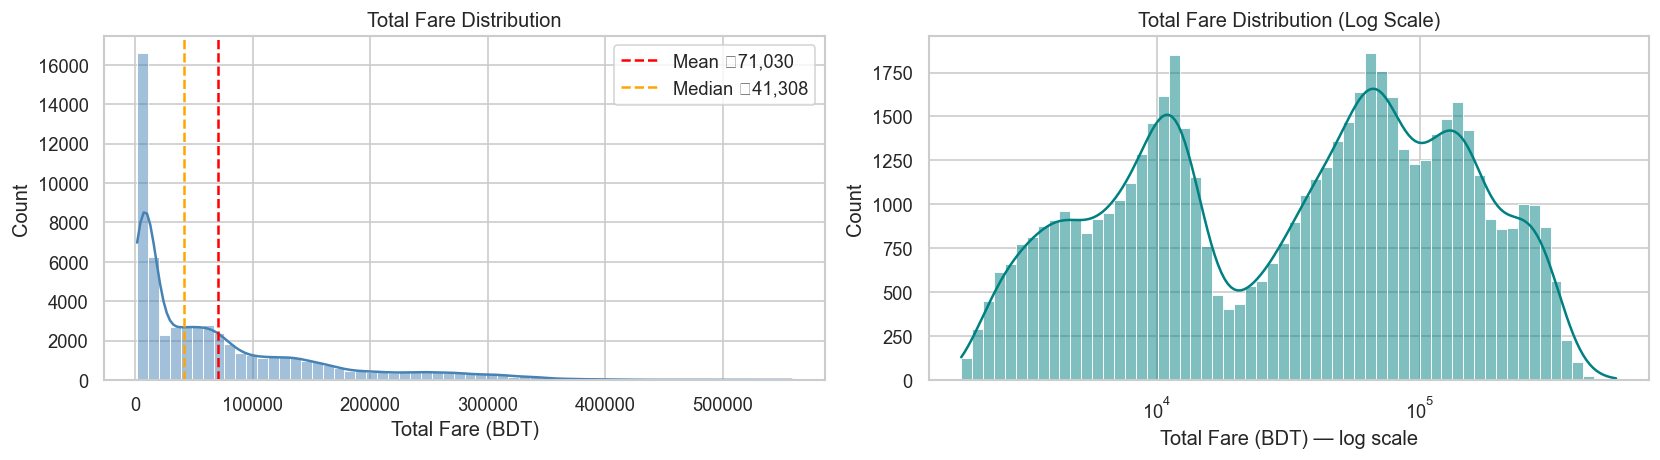

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram + KDE
sns.histplot(df_raw["total_fare_bdt"], kde=True, bins=60, color="steelblue", ax=axes[0])
axes[0].axvline(df_raw["total_fare_bdt"].mean(), color="red", linestyle="--", label=f'Mean ৳{df_raw["total_fare_bdt"].mean():,.0f}')
axes[0].axvline(df_raw["total_fare_bdt"].median(), color="orange", linestyle="--", label=f'Median ৳{df_raw["total_fare_bdt"].median():,.0f}')
axes[0].set_title("Total Fare Distribution")
axes[0].set_xlabel("Total Fare (BDT)")
axes[0].legend()

# Log scale version — helps see right-skewed data clearly
sns.histplot(df_raw["total_fare_bdt"], kde=True, bins=60, color="teal", ax=axes[1], log_scale=True)
axes[1].set_title("Total Fare Distribution (Log Scale)")
axes[1].set_xlabel("Total Fare (BDT) — log scale")

plt.tight_layout()
plt.show()


## 9. Outlier Heuristic — IQR × 1.5
Boxplots for all numeric columns. Points beyond the whiskers are flagged outliers.


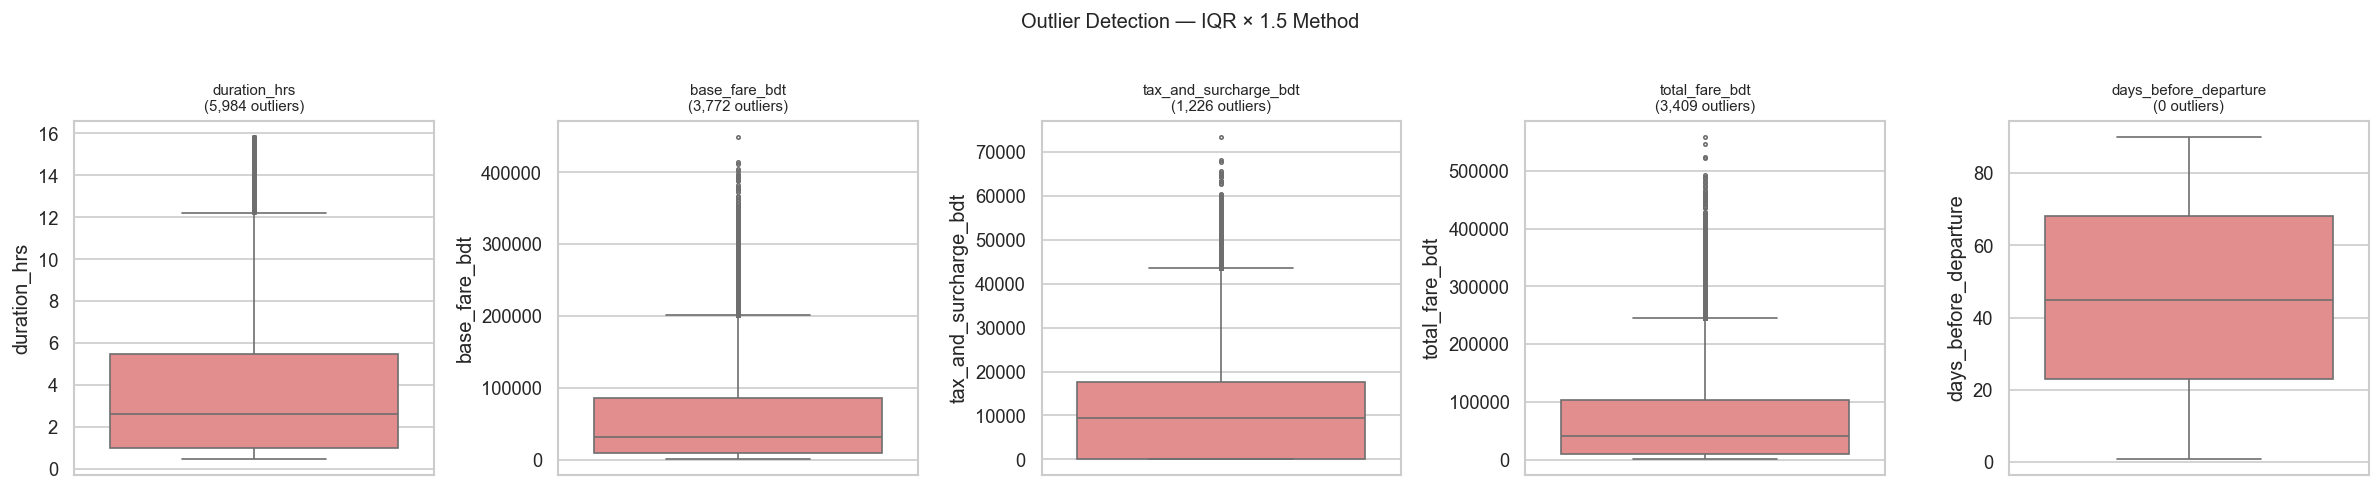

In [10]:
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(4 * len(numeric_cols), 4))
if len(numeric_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, numeric_cols):
    q1 = df_raw[col].quantile(0.25)
    q3 = df_raw[col].quantile(0.75)
    iqr = q3 - q1
    n_out = ((df_raw[col] < q1 - 1.5 * iqr) | (df_raw[col] > q3 + 1.5 * iqr)).sum()
    sns.boxplot(y=df_raw[col], color="lightcoral", ax=ax, fliersize=2)
    ax.set_title(f"{col}\n({n_out:,} outliers)", fontsize=9)
    ax.set_xlabel("")

plt.suptitle("Outlier Detection — IQR × 1.5 Method", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## 10. Categorical Column Distributions
Count plots for key categorical columns — reveals class imbalance and cardinality.


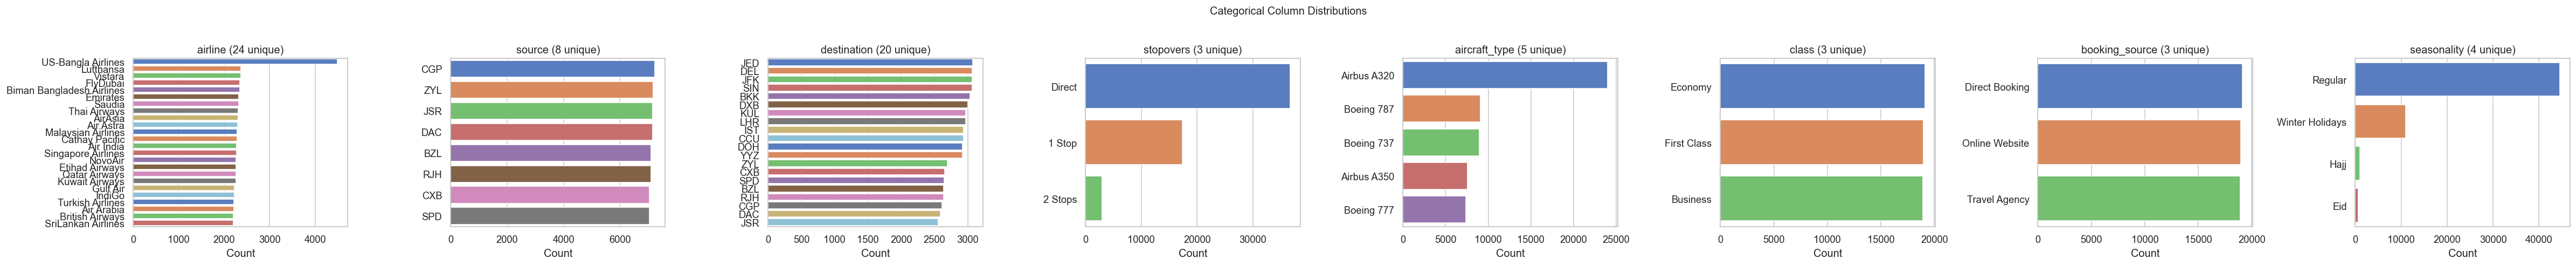

In [11]:
# Focus on low-cardinality categoricals (≤ 25 unique values — skip datetime cols)
plot_cols = [c for c in cat_cols
             if df_raw[c].nunique() <= 25
             and "date" not in c and "time" not in c and "name" not in c]

n = len(plot_cols)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
if n == 1:
    axes = [axes]

for ax, col in zip(axes, plot_cols):
    order = df_raw[col].value_counts().index
    sns.countplot(y=df_raw[col], order=order, palette="muted", ax=ax)
    ax.set_title(f"{col} ({df_raw[col].nunique()} unique)")
    ax.set_xlabel("Count")
    ax.set_ylabel("")

plt.suptitle("Categorical Column Distributions", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## 11. Fare by Seasonality
Boxplot showing fare spread per season — reveals both central tendency and outlier behaviour.


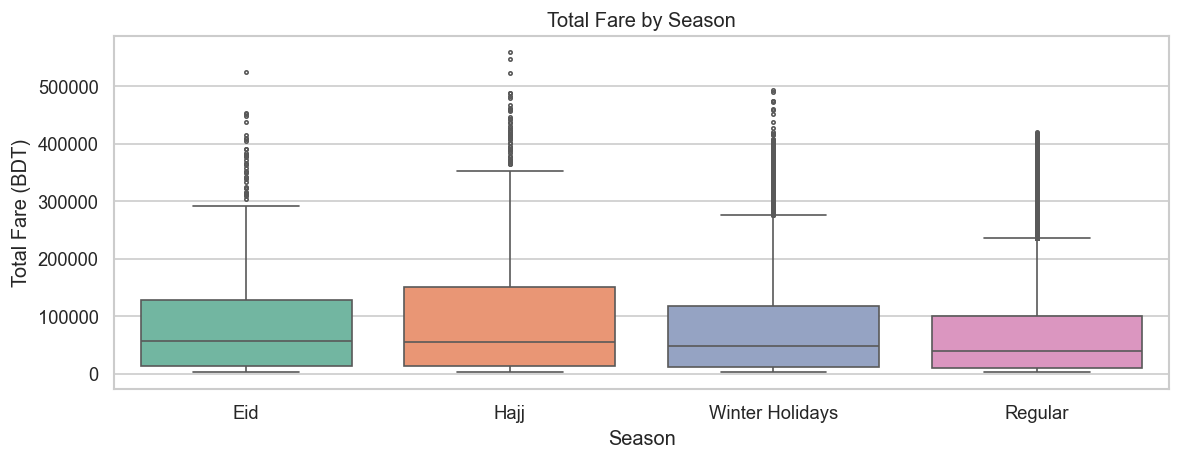

In [12]:
season_col = "seasonality" if "seasonality" in df_raw.columns else "season"

if season_col in df_raw.columns:
    order = df_raw.groupby(season_col)["total_fare_bdt"].median().sort_values(ascending=False).index
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.boxplot(data=df_raw, x=season_col, y="total_fare_bdt", order=order,
                palette="Set2", fliersize=2, ax=ax)
    ax.set_title("Total Fare by Season")
    ax.set_xlabel("Season")
    ax.set_ylabel("Total Fare (BDT)")
    plt.tight_layout()
    plt.show()
else:
    print("Season column not found in raw data.")


## 12. Fare by Airline
Median fare per airline, sorted — helps spot pricing tiers.


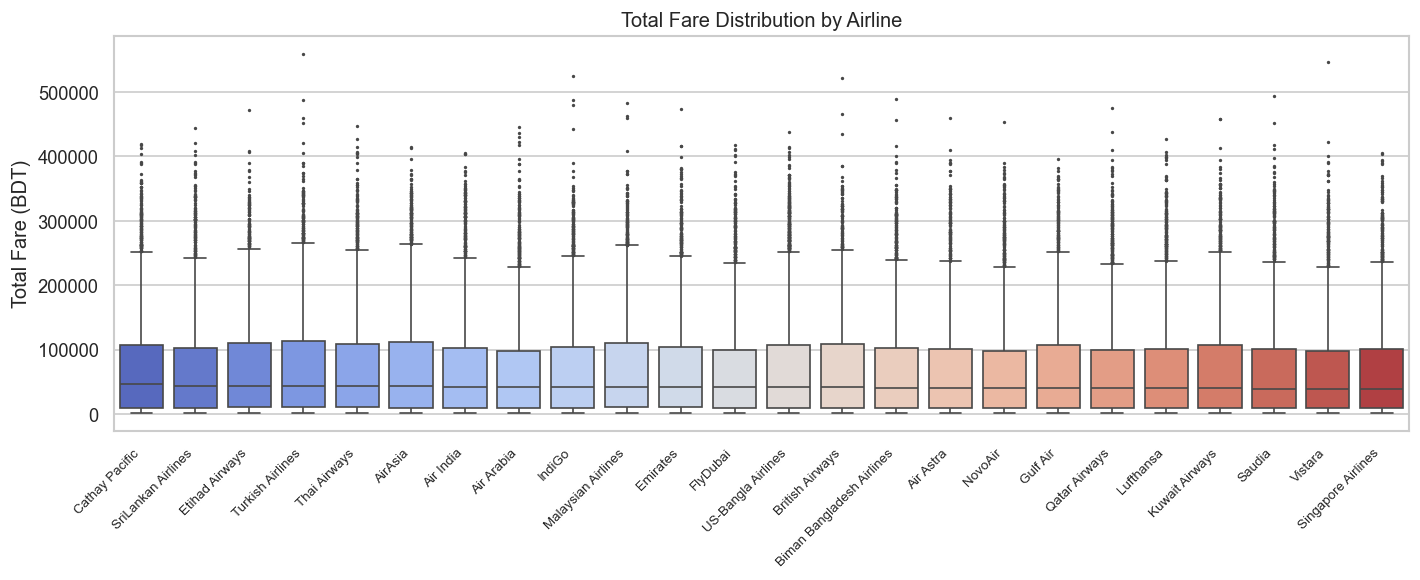

In [13]:
if "airline" in df_raw.columns:
    order = df_raw.groupby("airline")["total_fare_bdt"].median().sort_values(ascending=False).index
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.boxplot(data=df_raw, x="airline", y="total_fare_bdt", order=order,
                palette="coolwarm", fliersize=1, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
    ax.set_title("Total Fare Distribution by Airline")
    ax.set_ylabel("Total Fare (BDT)")
    ax.set_xlabel("")
    plt.tight_layout()
    plt.show()


## 13. Duration vs Fare
Scatter plot — the strongest numeric correlation (0.35) in your dataset.


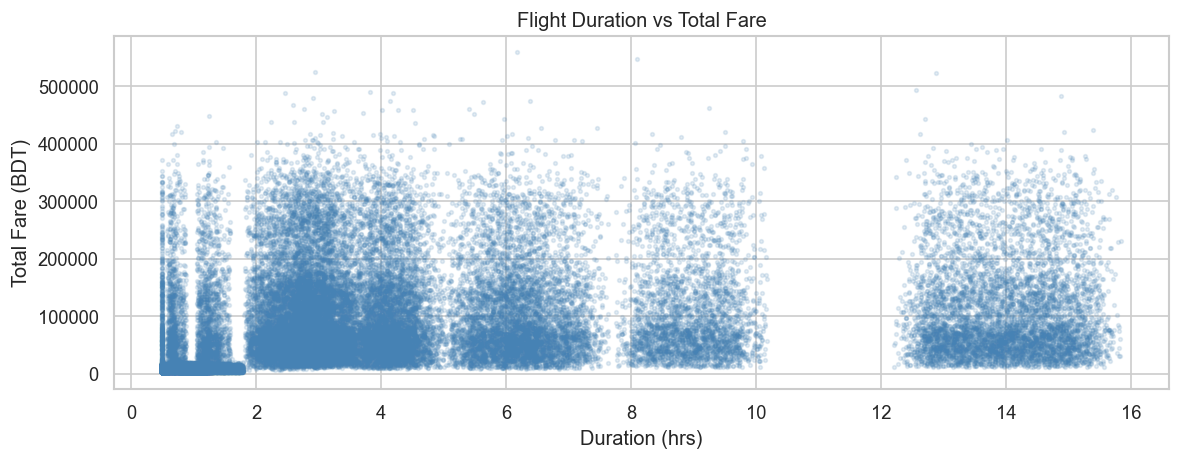

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(df_raw["duration_hrs"], df_raw["total_fare_bdt"],
           alpha=0.15, s=5, color="steelblue")
ax.set_xlabel("Duration (hrs)")
ax.set_ylabel("Total Fare (BDT)")
ax.set_title("Flight Duration vs Total Fare")
plt.tight_layout()
plt.show()


## 14. Correlation Heatmap
Numeric columns only. Shows linear relationships between all features.

> ⚠ **Leakage warning:** `base_fare_bdt` and `tax_and_surcharge_bdt` will show near-perfect correlation with `total_fare_bdt` — they directly compose it. Drop before modelling.


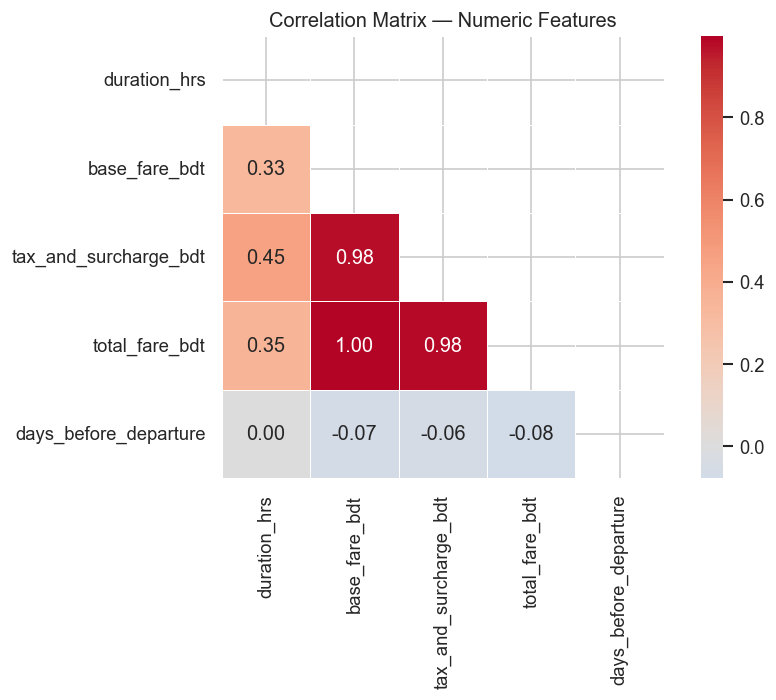

In [15]:
corr = df_raw.select_dtypes(include=[np.number]).corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()


## 15. Initial Observations & Assumptions

### Findings
| Area | Observation |
|---|---|
| **Missing data** | No true NaN values detected — but check for disguised nulls (empty strings, "unknown") in categorical columns |
| **Dtypes** | `departure_date_and_time` and `arrival_date_and_time` are `object` — must be parsed to `datetime64` |
| **Skew** | `total_fare_bdt` is right-skewed (mean ৳71K vs median ৳41K) — consider log transform for modelling |
| **Outliers** | `duration_hrs` (5,984), `base_fare_bdt` (3,772), `total_fare_bdt` (3,409) flagged — likely legitimate long-haul/business class tickets, not errors |
| **Categorical** | `stopovers` has 3 values (Direct, 1 Stop, 2 Stops) → encode as ordinal (0, 1, 2) |
| **Leakage** | `base_fare_bdt`, `tax_and_surcharge_bdt`, `fare_total_check` directly compose the target — **drop before modelling** |
| **Season imbalance** | 44,525 / 57,000 rows are "Regular" — model may underfit Hajj/Eid patterns |
| **Strongest feature** | `duration_hrs` (r = 0.35) is the only non-leakage numeric feature with meaningful correlation |

### Assumptions
- Dataset represents real Bangladesh domestic + international flight fares
- Outlier fares reflect genuine business/first class pricing, not data entry errors
- `days_before_departure` range 1–90 is intentional (booking window)

### Limitations
- IQR outlier flagging is heuristic only — domain knowledge should override
- Correlation heatmap shows linear relationships only — non-linear patterns not captured here
- Datetime columns not yet parsed — time-based features unavailable at this stage


In [ ]:
# Get feature names after label encoding
feature_names = data.feature_names

# Linear regression coefficients
lr = trained_models["Linear Regression"]
ridge = trained_models["Ridge Regression"]
lasso = trained_models["Lasso Regression"]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Linear": lr.coef_,
    "Ridge":  ridge.coef_,
    "Lasso":  lasso.coef_,
}).set_index("Feature").sort_values("Linear", ascending=False)

print(coef_df)